# One-Way Coupled Heat–Ambipolar Transport Model: Dimensionless Derivation

## Objective

The objective of this notebook is to derive the dimensionless form of the one-way coupled heat–ambipolar transport model.

The temperature field is first obtained by solving the dimensionless heat equation. The resulting temperature distribution acts as a source term in the ambipolar transport equation through the temperature Laplacian. Since the carrier concentration does not influence the heat equation, the coupling is one-way.

---

# 1. Dimensionless Heat Equation

From Notebook 01, the dimensionless heat equation is

$$
\boxed{
\frac{\partial \theta}{\partial \tau}
=
\frac{\partial^2\theta}{\partial X^2}
+
Q^*
}
$$

where

$$
Q^*=\frac{QL^2}{k\Delta T}.
$$

The dimensionless temperature satisfies

$$
\theta(0,\tau)=0,
$$

$$
\theta(1,\tau)=1.
$$

---

# 2. Dimensionless Ambipolar Transport Equation

From Notebook 03,

$$
\boxed{
\frac{\partial P}{\partial\tau}
=
Le
\frac{\partial^2P}{\partial X^2}
-
Pe
\frac{\partial P}{\partial X}
}
$$

where

$$
Le=\frac{D}{\alpha},
$$

and

$$
Pe=\frac{vL}{\alpha}.
$$

---

# 3. Dimensional Coupled Equation

The dimensional one-way coupled transport equation is

$$
\frac{\partial p}{\partial t}
=
D\frac{\partial^2p}{\partial x^2}
-
v\frac{\partial p}{\partial x}
+
DS_p
\frac{\partial^2T}{\partial x^2}.
$$

The last term represents thermal coupling.

---

# 4. Dimensionless Variables

Using the same characteristic scales as the previous notebooks,

Spatial coordinate

$$
X=\frac{x}{L},
$$

Dimensionless time

$$
\tau=\frac{\alpha t}{L^2},
$$

Dimensionless carrier concentration

$$
P=\frac{p}{p_0},
$$

Dimensionless temperature

$$
\theta=\frac{T-T_0}{\Delta T}.
$$

---

# 5. Transformation of the Coupling Term

Since

$$
T=T_0+\Delta T\theta,
$$

the second derivative becomes

$$
\frac{\partial^2T}{\partial x^2}
=
\frac{\Delta T}{L^2}
\frac{\partial^2\theta}{\partial X^2}.
$$

Therefore,

$$
DS_p
\frac{\partial^2T}{\partial x^2}
=
DS_p
\frac{\Delta T}{L^2}
\frac{\partial^2\theta}{\partial X^2}.
$$

---

# 6. Dimensionless Governing Equation

Substituting every transformed term into the dimensional transport equation gives

$$
p_0
\frac{\alpha}{L^2}
\frac{\partial P}{\partial\tau}
=
D
\frac{p_0}{L^2}
\frac{\partial^2P}{\partial X^2}
-
v
\frac{p_0}{L}
\frac{\partial P}{\partial X}
+
DS_p
\frac{\Delta T}{L^2}
\frac{\partial^2\theta}{\partial X^2}.
$$

Dividing throughout by

$$
\frac{p_0\alpha}{L^2},
$$

gives

$$
\frac{\partial P}{\partial\tau}
=
\frac{D}{\alpha}
\frac{\partial^2P}{\partial X^2}
-
\frac{vL}{\alpha}
\frac{\partial P}{\partial X}
+
\frac{DS_p\Delta T}{p_0\alpha}
\frac{\partial^2\theta}{\partial X^2}.
$$

---

# 7. Coupling Parameter

Define the dimensionless coupling parameter

$$
\boxed{
\Lambda
=
\frac{DS_p\Delta T}{p_0\alpha}
}
$$

This parameter measures the strength of thermal coupling relative to carrier transport.

- Small values of $\Lambda$ indicate weak thermal coupling.
- Large values of $\Lambda$ indicate strong thermal influence on carrier transport.

---

# 8. Final Dimensionless Coupled Equation

The complete one-way coupled transport equation becomes

$$
\boxed{
\frac{\partial P}{\partial\tau}
=
Le
\frac{\partial^2P}{\partial X^2}
-
Pe
\frac{\partial P}{\partial X}
+
\Lambda
\frac{\partial^2\theta}{\partial X^2}
}
$$

The heat equation remains

$$
\boxed{
\frac{\partial \theta}{\partial \tau}
=
\frac{\partial^2\theta}{\partial X^2}
+
Q^*
}
$$

---

# 9. One-Way Coupling Strategy

The coupled model is solved sequentially:

1. Solve the dimensionless heat equation.
2. Obtain the temperature field $\theta(X,\tau)$.
3. Compute the temperature Laplacian

$$
\frac{\partial^2\theta}{\partial X^2}.
$$

4. Use the temperature Laplacian as the source term in the ambipolar transport equation.
5. Solve the transport equation for the carrier concentration.

Since the transport equation depends on the temperature field, but the heat equation does not depend on the carrier concentration, the model represents **one-way coupling**.

---

# 10. Summary of Dimensionless Parameters

| Symbol | Definition | Physical Meaning |
|---------|------------|------------------|
| $Q^*$ | $\dfrac{QL^2}{k\Delta T}$ | Dimensionless heat source |
| $Le$ | $\dfrac{D}{\alpha}$ | Diffusion ratio |
| $Pe$ | $\dfrac{vL}{\alpha}$ | Péclet number |
| $\Lambda$ | $\dfrac{DS_p\Delta T}{p_0\alpha}$ | Thermal coupling parameter |

---

# Conclusion

The one-way coupled heat–ambipolar transport model has been successfully transformed into a dimensionless form using the same characteristic scales employed for the individual heat and transport equations. The resulting formulation introduces a new dimensionless parameter, $\Lambda$, which quantifies the influence of the temperature field on carrier transport. This dimensionless coupled model provides the mathematical foundation for the numerical implementation presented in the next notebook.

Heat equation converged after 440 steps
Uncoupled transport converged after 511 steps
Coupled transport converged after 520 steps

Maximum Difference : 0.06081985352604574
L2 Difference      : 0.04405673886791248


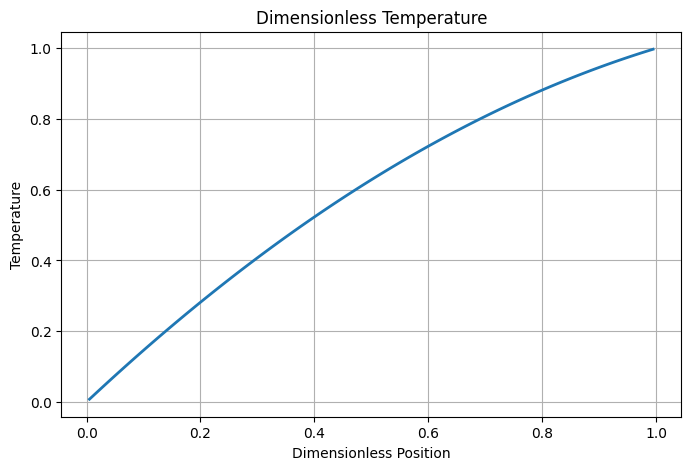

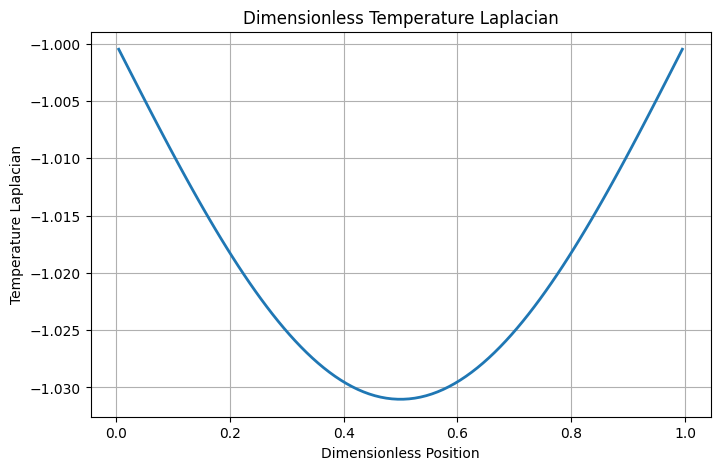

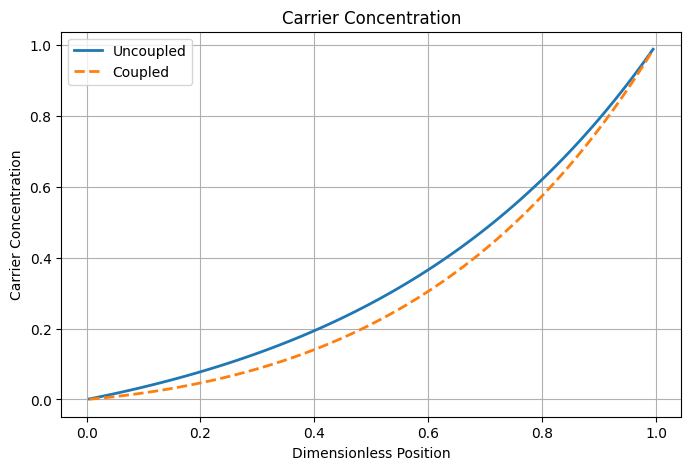

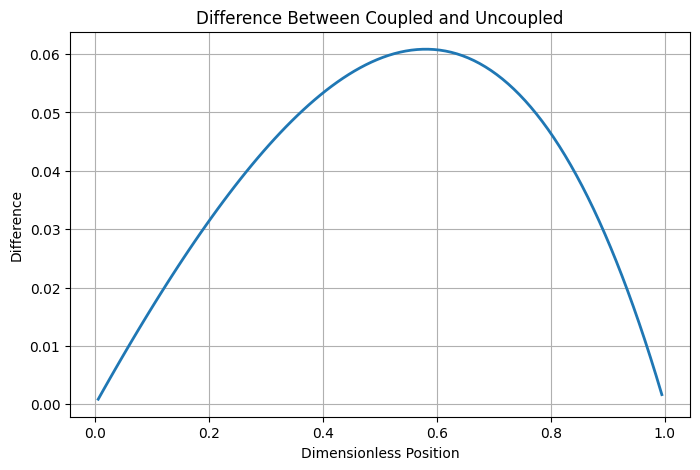


COUPLED MODEL SUMMARY
Heat Source (Q*)        : 1.0
Diffusion Ratio (Le)    : 1.0
Peclet Number (Pe)      : 2.0
Coupling Parameter (Λ)  : 0.5

Maximum Difference : 6.081985e-02
L2 Difference      : 4.405674e-02


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *

# Dimensionless One-Way Coupled Heat–Ambipolar Model

# Heat:- ∂θ/∂τ = ∂²θ/∂X² + Q*

# Transport:- ∂P/∂τ = Le∂²P/∂X² − Pe∂P/∂X + Λ∂²θ/∂X²

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

# Dimensionless Parameters
Q_star = 1.0
Le = 1.0
Pe = 2.0
Lambda = 0.5      # Coupling strength

dt = 1e-3
max_steps = 10000
tolerance = 1e-8

# HEAT EQUATION

theta = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi * mesh.cellCenters[0]),
    name="Temperature"
)

theta.constrain(0.0, mesh.facesLeft)
theta.constrain(1.0, mesh.facesRight)

heatEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + Q_star
)

for step in range(max_steps):

    old = theta.value.copy()

    heatEq.solve(var=theta, dt=dt)

    if np.max(np.abs(theta.value - old)) < tolerance:
        print(f"Heat equation converged after {step+1} steps")
        break

temperatureLaplacian = theta.faceGrad.divergence # TEMPERATURE LAPLACIAN

# UNCOUPLED TRANSPORT

P_uncoupled = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi * mesh.cellCenters[0]),
    name="Uncoupled"
)

P_uncoupled.constrain(0.0, mesh.facesLeft)
P_uncoupled.constrain(1.0, mesh.facesRight)

transportEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=Le)
    -
    PowerLawConvectionTerm(coeff=(Pe,))
)

for step in range(max_steps):

    old = P_uncoupled.value.copy()

    transportEq.solve(var=P_uncoupled, dt=dt)

    if np.max(np.abs(P_uncoupled.value-old)) < tolerance:
        print(f"Uncoupled transport converged after {step+1} steps")
        break

# COUPLED TRANSPORT

P_coupled = CellVariable(
    mesh=mesh,
    value=np.sin(np.pi * mesh.cellCenters[0]),
    name="Coupled"
)

P_coupled.constrain(0.0, mesh.facesLeft)
P_coupled.constrain(1.0, mesh.facesRight)

coupledEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=Le)
    -
    PowerLawConvectionTerm(coeff=(Pe,))
    +
    Lambda * temperatureLaplacian
)

for step in range(max_steps):

    old = P_coupled.value.copy()

    coupledEq.solve(var=P_coupled, dt=dt)

    if np.max(np.abs(P_coupled.value-old)) < tolerance:
        print(f"Coupled transport converged after {step+1} steps")
        break

difference = np.abs(P_coupled.value - P_uncoupled.value)

max_difference = difference.max()
l2_difference = np.sqrt(np.mean(difference**2))

print("\nMaximum Difference :", max_difference)
print("L2 Difference      :", l2_difference)

x = np.array(mesh.cellCenters[0])

plt.figure(figsize=(8,5))
plt.plot(x, theta.value, linewidth=2)
plt.grid(True)
plt.xlabel("Dimensionless Position")
plt.ylabel("Temperature")
plt.title("Dimensionless Temperature")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x, np.array(temperatureLaplacian), linewidth=2)
plt.grid(True)
plt.xlabel("Dimensionless Position")
plt.ylabel("Temperature Laplacian")
plt.title("Dimensionless Temperature Laplacian")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x, P_uncoupled.value, linewidth=2, label="Uncoupled")
plt.plot(x, P_coupled.value, "--", linewidth=2, label="Coupled")
plt.grid(True)
plt.legend()
plt.xlabel("Dimensionless Position")
plt.ylabel("Carrier Concentration")
plt.title("Carrier Concentration")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x, difference, linewidth=2)
plt.grid(True)
plt.xlabel("Dimensionless Position")
plt.ylabel("Difference")
plt.title("Difference Between Coupled and Uncoupled")
plt.show()

print("\n==============================")
print("COUPLED MODEL SUMMARY")
print("==============================")

print(f"Heat Source (Q*)        : {Q_star}")
print(f"Diffusion Ratio (Le)    : {Le}")
print(f"Peclet Number (Pe)      : {Pe}")
print(f"Coupling Parameter (Λ)  : {Lambda}")

print(f"\nMaximum Difference : {max_difference:.6e}")
print(f"L2 Difference      : {l2_difference:.6e}")